## K-Means: How to Choose K


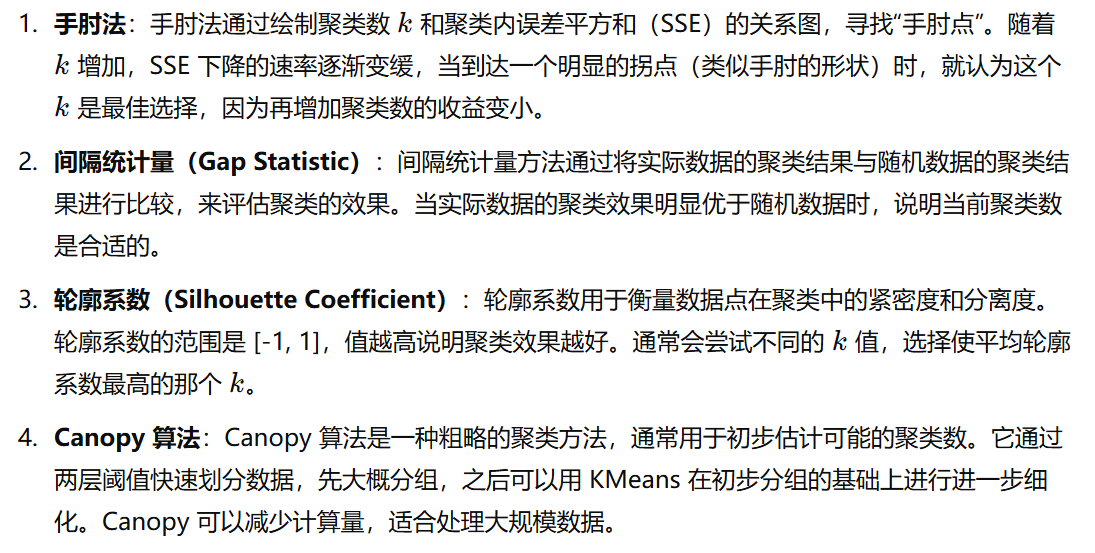

### 手肘法
手肘法通过观察不同k值下的簇内误差平方和（SSE）的变化来选择最佳的k值。当k值增加时，SSE会减小，但当k值达到某个点时，SSE的下降速度会明显减慢，这个点就是肘部。

![](https://www.biaodianfu.com/wp-content/uploads/2020/09/Elbow-Method-768x384.jpg)

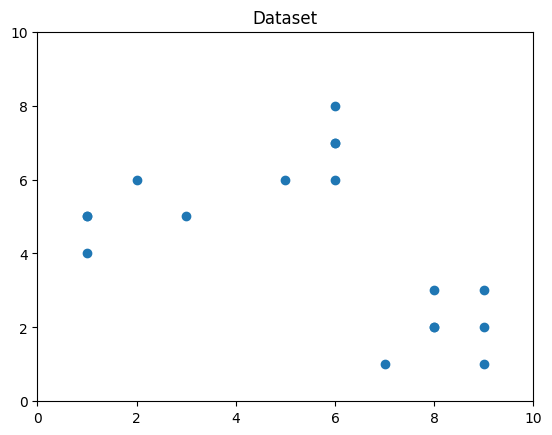

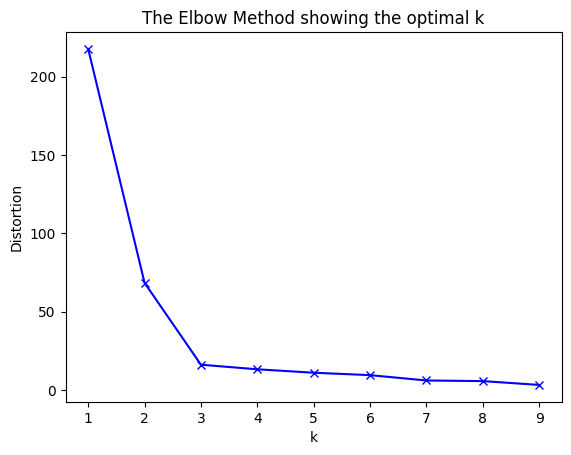

In [1]:
# clustering dataset
# determine k using elbow method
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6, 7, 8, 9, 8, 9, 9, 8])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7, 1, 2, 1, 2, 3, 2, 3])

plt.plot()
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.title('Dataset')
plt.scatter(x1, x2)
plt.show()

X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)

distortions = []
K = range(1, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init = 'auto').fit(X)
    distortions.append(kmeanModel.inertia_)

plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()


### 间隔统计量 Gap Statistic

间隔统计量（Gap Statistic）的原理是通过比较数据集中聚类内部的距离与随机分布数据集的期望距离来判定最佳聚类数量。间隔统计量在帮助我们确定聚类数量k方面的具体作用体现在参考对比、标准差修正、Gap值计算等方面。

原理：
间隔统计量基于蒙特卡洛模拟，通过生成多个随机分布的参考数据集，计算每个数据集的聚类内部距离总和，并求取这些距离总和的对数平均值作为期望距离。随后，计算实际数据集的聚类内部距离总和的对数与期望距离之差，即为Gap值。Gap值随聚类数量k的变化而变化，通常随着k的增加，Gap值会下降。最佳聚类数量k通常对应Gap值最大或开始稳定的位置。

In [2]:
import numpy as np
from scipy.spatial.distance import euclidean
from sklearn.cluster import KMeans as k_means

# 欧几里得距离作为默认的距离度量方法
dst = euclidean

# KMeans聚类的参数字典
k_means_args_dict = {
    'n_clusters': 0,          # 聚类数，这个会在后面动态设置
    'init': 'k-means++',       # 使用k-means++方法初始化聚类中心
    'max_iter': 100,           # 最大迭代次数
    'n_init': 1,               # 重新运行聚类算法的次数
    'verbose': False,          # 是否输出详细信息
}

def gap(data, refs=None, nrefs=20, ks=range(1, 11)):
    """
    计算 Gap 统计量，用于确定数据集的最佳聚类数目。

    参数：
    data : NumPy 数组，形状为 (n_samples, n_features)，表示输入数据。
    refs : 可选，参考数据集。如果为 None，将生成随机参考数据。
    nrefs : 参考数据集的数量，用于与真实数据集进行对比。
    ks : 待测试的聚类数目列表。

    返回：
    ks : 输入的聚类数列表。
    gaps : 计算出的 Gap 统计量数组。
    """

    # 获取数据的形状信息
    shape = data.shape

    # 如果没有提供参考数据集，则生成随机参考数据集
    if refs is None: # 如果没有提供 refs 参考数据集，函数会自动生成
        # 找到 data 中每个特征的最大值和最小值。
        tops = data.max(axis=0)    # 每个特征的最大值
        bottoms = data.min(axis=0) # 每个特征的最小值

        # 计算出每个特征的范围（最大值减去最小值）。
        dists = tops - bottoms     # 每个特征的范围（最大值-最小值）

        # 生成 nrefs 个随机参考数据集
        # 然后生成一个随机的三维数组 rands，这个数组的形状是 (shape[0], shape[1], nrefs)
        # 其中 shape[0] 是样本数量，shape[1] 是特征数量，nrefs 是要生成的参考数据集的数量。
        rands = np.random.random_sample(size=(shape[0], shape[1], nrefs))

        # 对于每个参考数据集（即 rands 的第三个维度），将其缩放，让它的范围和 data 的范围相同。
        for i in range(nrefs):
            rands[:, :, i] = rands[:, :, i] * dists + bottoms  # 缩放随机数据使其在相同范围内
    else:
        rands = refs  # 如果提供了参考数据集，直接使用

    # 初始化一个和 ks 长度一样的全零数组 gaps，用于存储每个 k 对应的 Gap 统计量
    gaps = np.zeros((len(ks),))

    # 对于每个候选的聚类数 k 进行计算
    for i, k in enumerate(ks):
        # 设置当前的聚类数 k
        k_means_args_dict['n_clusters'] = k
        kmeans = k_means(**k_means_args_dict)  # 创建 KMeans 对象
        kmeans.fit(data)  # 对真实数据进行聚类
        cluster_centers, point_labels = kmeans.cluster_centers_, kmeans.labels_  # 获取聚类中心和每个点的标签

        # 计算真实数据的群内离差（dispersion）
        # 通过计算每个数据点到其所属聚类中心的距离并求和得到的
        disp = sum(
            [dst(data[current_row_index, :], cluster_centers[point_labels[current_row_index], :])
             for current_row_index in range(shape[0])])

        # 初始化 refdisps 数组，用于存储每个参考数据集的群内离差
        refdisps = np.zeros((rands.shape[2],))

        # 对每个参考数据集计算群内离差
        for j in range(rands.shape[2]):
            kmeans = k_means(**k_means_args_dict)  # 对参考数据集进行相同的聚类
            kmeans.fit(rands[:, :, j])
            cluster_centers, point_labels = kmeans.cluster_centers_, kmeans.labels_
            refdisps[j] = sum(
                [dst(rands[current_row_index, :, j], cluster_centers[point_labels[current_row_index], :])
                 for current_row_index in range(shape[0])])

        # 计算 Gap 统计量：参考数据的平均对数群内离差 - 真实数据的对数群内离差
        gaps[i] = np.mean(np.log(refdisps)) - np.log(disp)

    # 返回聚类数列表和对应的 Gap 统计量
    return ks, gaps

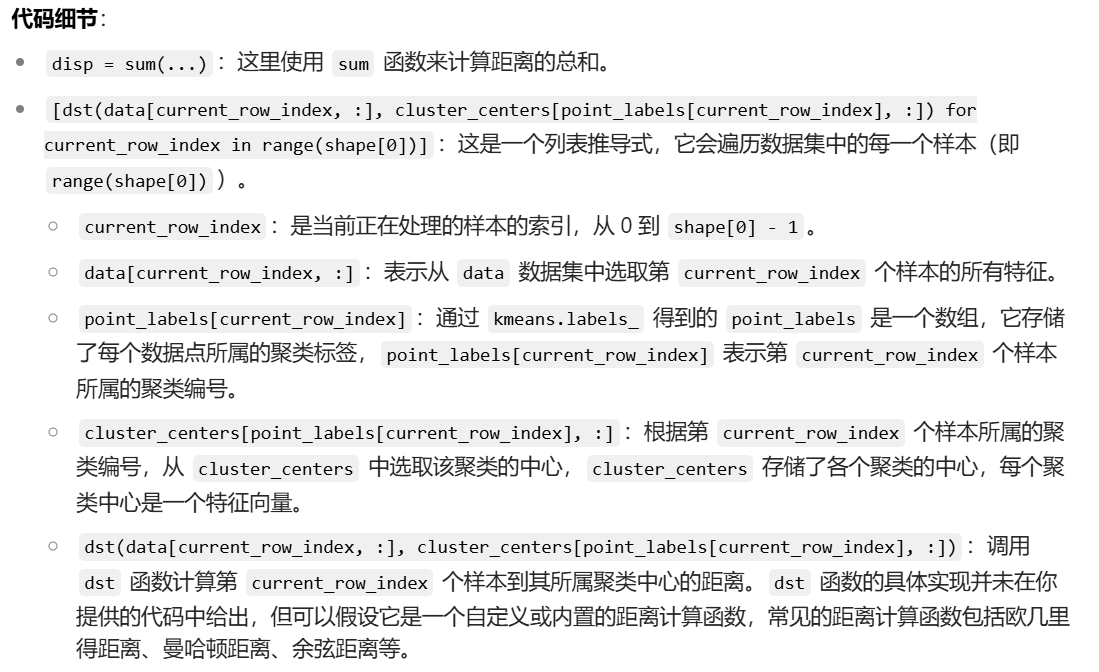

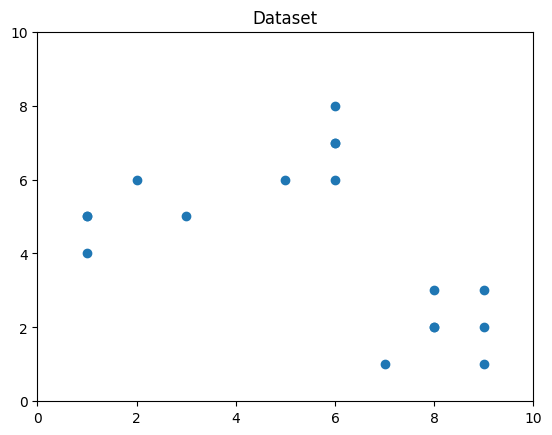

Optimal number of clusters: 3


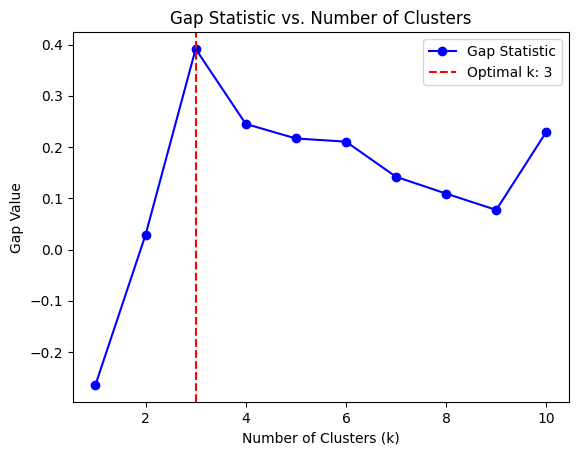

In [3]:
import numpy as np
from sklearn.datasets import make_blobs

# 生成模拟数据
x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6, 7, 8, 9, 8, 9, 9, 8])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7, 1, 2, 1, 2, 3, 2, 3])

plt.plot()
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.title('Dataset')
plt.scatter(x1, x2)
plt.show()

X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)


ks, gaps = gap(X, nrefs=20, ks=range(1, 11))

# 找到 Gap 值最大的 k
optimal_k = ks[np.argmax(gaps)]

print(f"Optimal number of clusters: {optimal_k}")

# 绘制 Gap 统计量图
plt.plot(ks, gaps, 'bo-', label='Gap Statistic')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Value')
plt.title('Gap Statistic vs. Number of Clusters')
plt.axvline(optimal_k, linestyle='--', color='r', label=f'Optimal k: {optimal_k}')
plt.legend()
plt.show()


### 轮廓系数（Silhouette Coefficient）

轮廓系数（Silhouette Coefficient）是一种用于评估聚类效果的指标，它结合了聚类的凝聚度（Cohesion）和分离度（Separation）。轮廓系数的取值范围是[-1,1]，取值越接近1表示聚类效果越好，取值越接近-1则表示聚类效果较差。

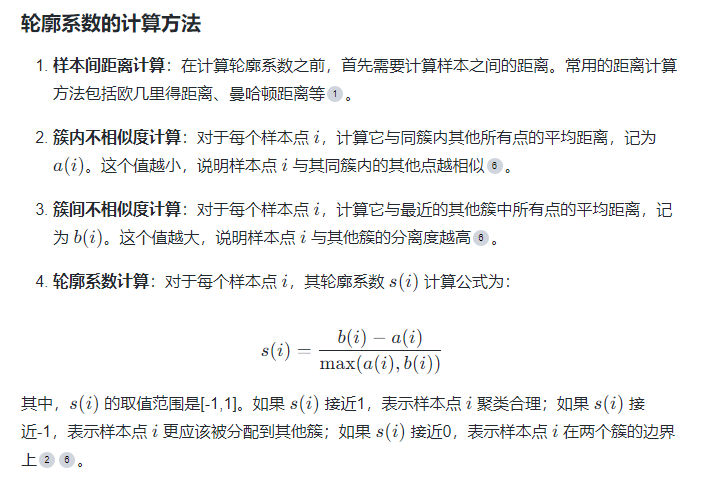

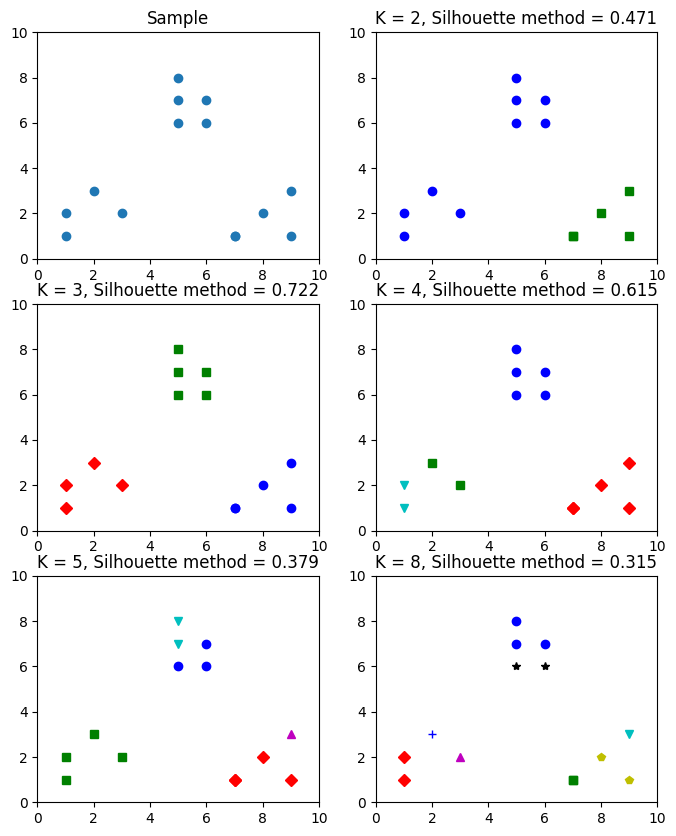

In [4]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn import metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.subplot(3, 2, 1)
x1 = np.array([1, 2, 3, 1, 5, 6, 5, 5, 6, 7, 8, 9, 7, 9])
x2 = np.array([1, 3, 2, 2, 8, 6, 7, 6, 7, 1, 2, 1, 1, 3])
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.title('Sample')
plt.scatter(x1, x2)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'b']
markers = ['o', 's', 'D', 'v', '^', 'p', '*', '+']
tests = [2, 3, 4, 5, 8]
subplot_counter = 1
for t in tests:
    subplot_counter += 1
    plt.subplot(3, 2, subplot_counter)
    kmeans_model = KMeans(n_clusters=t, n_init = 'auto').fit(X)
    for i, l in enumerate(kmeans_model.labels_):
        plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None')
        plt.xlim([0, 10])
        plt.ylim([0, 10])
        plt.title('K = %s, Silhouette method = %.03f' % (t, metrics.silhouette_score(X, kmeans_model.labels_,metric='euclidean')))
plt.show()

For n_clusters = 2, the silhouette score is 0.471
For n_clusters = 3, the silhouette score is 0.722
For n_clusters = 4, the silhouette score is 0.644


For n_clusters = 5, the silhouette score is 0.555
For n_clusters = 6, the silhouette score is 0.379
For n_clusters = 7, the silhouette score is 0.361
For n_clusters = 8, the silhouette score is 0.315


For n_clusters = 9, the silhouette score is 0.294
For n_clusters = 10, the silhouette score is 0.240


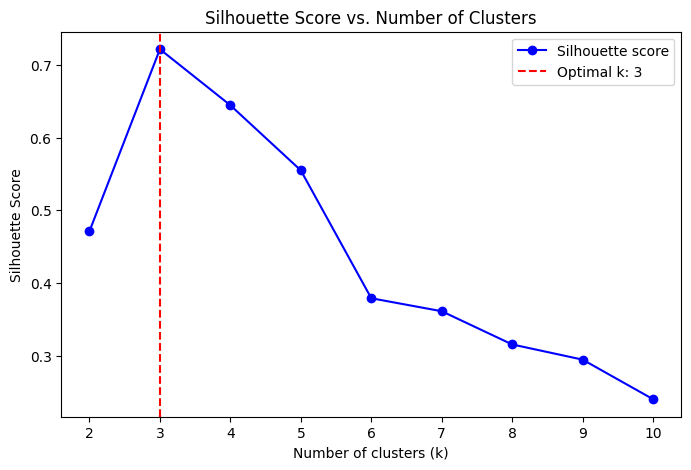

Optimal number of clusters (k) is 3


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# 准备数据
x1 = np.array([1, 2, 3, 1, 5, 6, 5, 5, 6, 7, 8, 9, 7, 9])
x2 = np.array([1, 3, 2, 2, 8, 6, 7, 6, 7, 1, 2, 1, 1, 3])
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)

# 计算不同 k 值下的轮廓系数
silhouette_scores = []
ks = range(2, 11)  # 测试的 k 值范围，从 2 到 10

for k in ks:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the silhouette score is {silhouette_avg:.3f}")

# 绘制 k 与轮廓系数的关系图
optimal_k = ks[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 5))
plt.plot(ks, silhouette_scores, 'bo-', label='Silhouette score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.axvline(optimal_k, linestyle='--', color='r', label=f'Optimal k: {optimal_k}')
plt.legend()
plt.show()

print(f"Optimal number of clusters (k) is {optimal_k}")

### Canopy算法

肘部法则（Elbow Method）和轮廓系数（Silhouette Coefficient）来对k值进行最终的确定，但是这些方法都是属于“事后”判断的，而Canopy算法的作用就在于它是通过事先粗聚类的方式，为k-means算法确定初始聚类中心个数和聚类中心点。

与传统的聚类算法(比如K-Means)不同，Canopy聚类最大的特点是不需要事先指定k值(即clustering的个数)，因此具有很大的实际应用价值。与其他聚类算法相比，Canopy聚类虽然精度较低，但其在速度上有很大优势，因此可以使用Canopy聚类先对数据进行“粗”聚类，得到k值，以及大致的k个中心点，再使用K-Means进行进一步“细”聚类。所以Canopy+K-Means这种形式聚类算法聚类效果良好。


**Canopy 算法概述**：
Canopy 算法是一种聚类算法，它具有独特的优势，尤其在与 K-Means 算法结合使用时可以发挥很好的效果。

**特点**：

1. 无需预先指定 k 值
   - 与传统的聚类算法（如 K-Means）不同，Canopy 算法不需要事先确定聚类的数量 `k`。这在实际应用中非常有用，因为很多时候我们可能并不知道数据集中应该分为几个聚类才是最合适的。
   - 对于那些难以估计 `k` 值的数据集，Canopy 算法可以先进行一次粗聚类，为后续的精确聚类提供基础。
2. 速度优势
   - 虽然 Canopy 算法的聚类精度相对较低，但它的计算速度较快。在处理大规模数据时，它可以在较短的时间内对数据进行一个大致的聚类处理。

**工作原理**：
Canopy 算法的基本思路是通过设置两个距离阈值 `T1` 和 `T2`（通常 `T1 > T2`）来实现聚类。对于数据集中的每个点：

- 当一个点与一个 Canopy 的中心距离小于 `T1` 时，将该点添加到这个 Canopy 中。
- 当一个点与一个 Canopy 的中心距离小于 `T2` 时，将该点标记为这个 Canopy 的成员，并且更新这个 Canopy 的中心（例如，重新计算中心为成员点的平均值）。

**与 K-Means 结合使用的优势**：

- 粗聚类确定 k 值和中心
  - 首先使用 Canopy 算法对数据进行粗聚类，通过这个过程可以得到一个大致的聚类中心数量 `k` 以及 `k` 个中心点。
  - 因为 Canopy 算法处理速度快，它可以快速对数据进行一个初步的划分，即使这个划分不是非常精确，但可以为后续的 K-Means 算法提供有用的信息。
- K-Means 进行细聚类
  - 然后使用 K-Means 算法，将 Canopy 算法得到的 `k` 个中心点作为 K-Means 算法的初始聚类中心，再进行更精确的聚类。
  - K-Means 算法在已知 `k` 值和初始聚类中心的情况下，可以更精确地对数据进行聚类，优化聚类结果。

**性能权衡**：

- Canopy 算法作为粗聚类算法，虽然聚类精度较低，但在处理大规模数据时可以快速处理，减少了计算量和时间成本。
- K-Means 算法可以在 Canopy 算法提供的初始信息基础上进行更精确的聚类，两者结合可以在保证一定速度的同时，提高聚类的质量，达到较好的聚类效果。

**使用场景**：

- 对于大规模数据集，并且对聚类精度要求不是非常高，对聚类速度要求较高的场景，可以使用 Canopy 算法进行初步聚类。
- 当需要对聚类结果进行进一步细化和精确化时，可以使用 K-Means 算法进行后续处理。

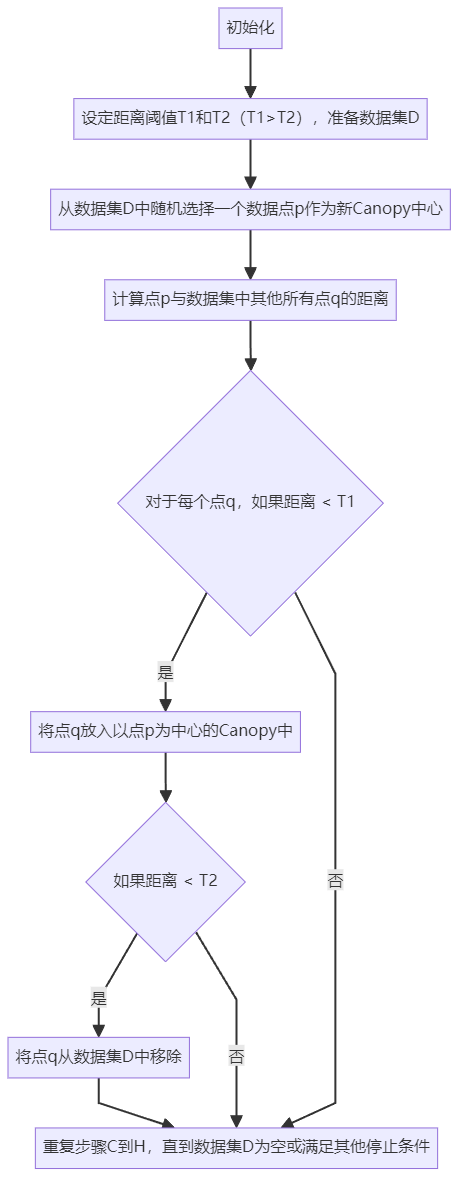

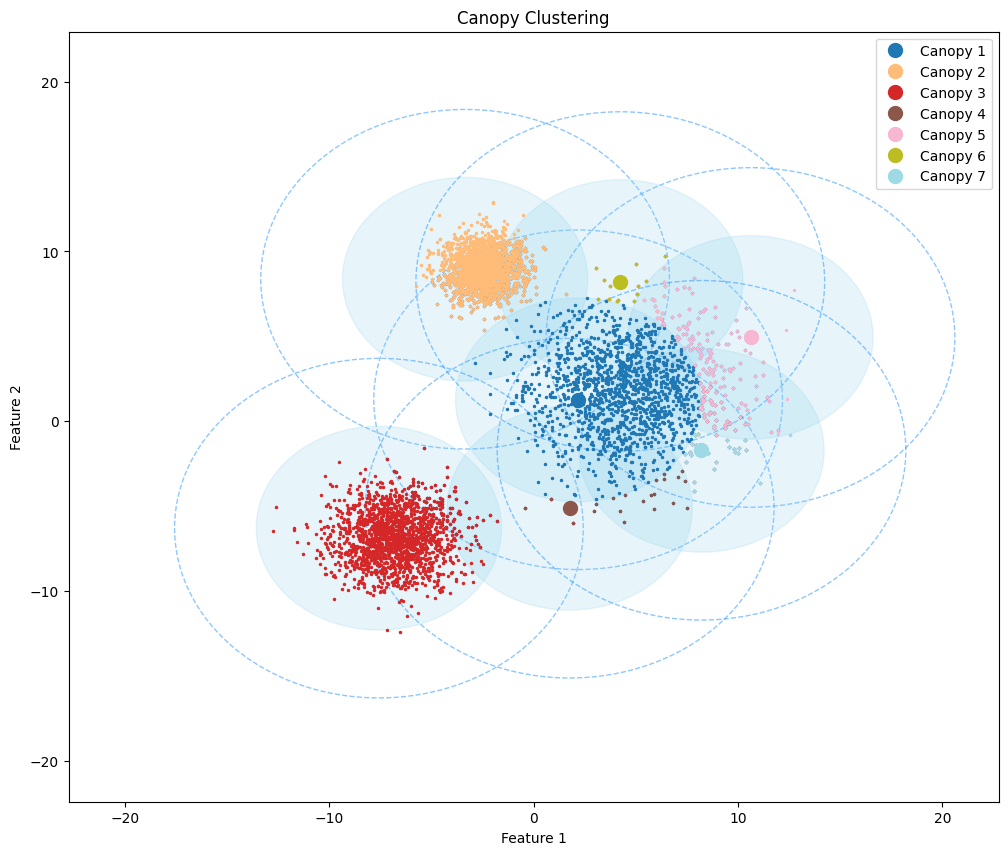

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import pairwise_distances

# Canopy聚类算法
class CanopyClustering:
    def __init__(self, T1, T2, distance_metric='euclidean'):
        """
        T1: 外阈值，用于确定Canopy覆盖的点
        T2: 内阈值，用于确定Canopy中心
        distance_metric: 使用的距离度量，如欧氏距离 'euclidean'
        """
        self.T1 = T1
        self.T2 = T2
        self.distance_metric = distance_metric
        self.canopies = []

    def fit(self, X):
        """
        执行Canopy聚类算法
        X: 输入数据，形状为 (n_samples, n_features)
        """
        canopies = []
        while len(X) > 0:
            # 随机选择一个点作为Canopy的中心
            center = X[0]
            X = np.delete(X, 0, 0)

            if len(X) == 0:
                break  # 如果没有剩余数据点，直接退出循环

            # 计算中心与所有其他点的距离
            distances = pairwise_distances([center], X, metric=self.distance_metric)[0]

            # 根据T1找到属于当前Canopy的所有点
            canopy = X[distances < self.T1]

            # 将属于Canopy但小于T2距离的点删除
            X = X[distances >= self.T2]

            # 保存当前Canopy
            canopies.append((center, canopy))

        self.canopies = canopies
        return self

def show_canopy(canopies, dataset, t1, t2):
    """绘制Canopy聚类结果"""
    fig, ax = plt.subplots(figsize=[12, 10])

    # 生成颜色列表
    colors = plt.cm.tab20(np.linspace(0, 1, len(canopies)))

    for i, (center, components) in enumerate(canopies):
        color = colors[i]
        ax.plot(center[0], center[1], 'o', color=color, markersize=10, label=f'Canopy {i+1}')

        t1_circle = plt.Circle((center[0], center[1]), radius=t1, color='dodgerblue', fill=False, linestyle='--', alpha=0.5)
        t2_circle = plt.Circle((center[0], center[1]), radius=t2, color='skyblue', alpha=0.2)

        ax.add_artist(t1_circle)
        ax.add_artist(t2_circle)

        # 确保 components 是二维数组并且不为空
        if components.size > 0:
            components = np.atleast_2d(components)
            ax.plot(components[:, 0], components[:, 1], '.', color=color, markersize=3)

    ax.set_xlim(dataset[:, 0].min() - t1, dataset[:, 0].max() + t1)
    ax.set_ylim(dataset[:, 1].min() - t1, dataset[:, 1].max() + t1)
    ax.set_title('Canopy Clustering')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    plt.show()

# 人工数据生成函数
def generate_artificial_datasets(n_samples=300, n_clusters=3, n_features=2, cluster_std=1.0, random_state=None):
    """
    生成用于测试聚类算法的人工数据集
    """
    X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features,
                      cluster_std=cluster_std, random_state=random_state)
    return X, y

# 测试代码：生成数据并使用Canopy聚类
if __name__ == '__main__':
    # 生成测试数据
    X, y = generate_artificial_datasets(n_samples=5000, n_clusters=3, cluster_std=[1.0, 2.5, 1.5], random_state=42)

    # 定义Canopy阈值
    T1 = 10.0
    T2 = 6.0

    # 执行Canopy聚类
    canopy = CanopyClustering(T1, T2)
    canopy.fit(X)

    # 可视化Canopy聚类结果
    show_canopy(canopy.canopies, X, T1, T2)
